# Analyze COVID Trajectories

Covariate-free analysis of generated COVID severity trajectories.

## 1. Load Everything

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform
from sklearn.cluster import AgglomerativeClustering
from umap import UMAP

sns.set_context("paper")

PROJECT_ROOT = Path.cwd().parents[1]

RESULTS_DIR = PROJECT_ROOT / "results" / "covid" / "generated_trajectories"
DATA_DIR = PROJECT_ROOT / "data" / "covid"

pink_cmap = sns.blend_palette(["#BE77CE", "#589ECD", "#1B19C3"], as_cmap=True)
cluster_palette = {"1":"#5878E1", "2":"#AF3978", "3":"#2B29AF", "4":"#970FA3"}
N_TRAJECTORY_CLUSTERS = 3

In [4]:
runs = []
for n in range(5):
    run_n = pd.read_csv(RESULTS_DIR / f"replicate_0{n + 1}_seed_{n + 42}.csv")
    runs.append(run_n)

runs = pd.concat(runs, ignore_index=True)
runs["abs_velocity"] = runs["velocity"].abs()
runs = runs[runs["datasplit"] == "val"]
proteins = runs["protein"].unique()
n_proteins = len(proteins)

display(runs["replicate"].unique())
runs.head()

array([1, 2, 3, 4, 5])

,start_sample,datasplit,replicate,seed,path_id,trajectory_replicate,step,t,protein,abundance,velocity,abs_velocity
570486,520_TOF1_AF_023_ZeBanC_P1_B7,val,1,42,0,0,0,0.00,ALB,16.734375,-0.859454,0.859454
570487,520_TOF1_AF_023_ZeBanC_P1_B7,val,1,42,0,0,1,0.02,ALB,16.718131,-0.766990,0.766990
570488,520_TOF1_AF_023_ZeBanC_P1_B7,val,1,42,0,0,2,0.04,ALB,16.703700,-0.678831,0.678831
570489,520_TOF1_AF_023_ZeBanC_P1_B7,val,1,42,0,0,3,0.06,ALB,16.690973,-0.597022,0.597022
570490,520_TOF1_AF_023_ZeBanC_P1_B7,val,1,42,0,0,4,0.08,ALB,16.679804,-0.523274,0.523274


In [5]:
quant = pd.read_csv(DATA_DIR / "quant.csv")
meta = pd.read_csv(DATA_DIR / "meta.csv")
annotations = pd.read_csv(DATA_DIR / "covid_uniprot_annotations.csv").fillna("")

who_grade = meta["WHO grade"].astype(float).replace(0.0, 3.0)
meta["WHO grade"] = who_grade
meta["time"] = (who_grade - 3.0) / (7.0 - 3.0)

rename_map = dict(zip(annotations["source_id"], annotations["display_name"]))
quant = quant.rename(columns=rename_map)
protein_cols = [
    col for col in quant.columns
    if col != "File" and pd.api.types.is_numeric_dtype(quant[col])
]

shared_proteins = sorted(set(protein_cols).intersection(runs["protein"]))

df = (
    quant.merge(meta, on="File", how="left")
    .melt(
        id_vars=["File", "time", "WHO grade"],
        value_vars=shared_proteins,
        var_name="protein",
        value_name="abundance",
    )
    .sort_values(["time", "File", "protein"])
    .reset_index(drop=True)
)

df.head()

,File,time,WHO grade,protein,abundance
0,520_TOF1_AF_023_ZeBanC_P1_B7,0.0,3.0,A1BG,10.635175
1,520_TOF1_AF_023_ZeBanC_P1_B7,0.0,3.0,A2M,12.694692
2,520_TOF1_AF_023_ZeBanC_P1_B7,0.0,3.0,AFM,8.286612
3,520_TOF1_AF_023_ZeBanC_P1_B7,0.0,3.0,AGT,8.279160
4,520_TOF1_AF_023_ZeBanC_P1_B7,0.0,3.0,AHSG,10.855956


## 1b. Predicted Versus Actual Abundance


In [6]:
t_bins = [0,  0.5, 1.0]
t_labels = [f"{start:.2f}-{end:.2f}" for start, end in zip(t_bins[:-1], t_bins[1:])]

actual_long = (
    df.assign(t_window=pd.cut(df["time"], bins=t_bins, labels=t_labels, include_lowest=True))
    .groupby(["protein", "t_window"], observed=True)
    .agg(actual=("abundance", "mean"), n_actual_samples=("File", "nunique"))
    .reset_index()
)

predicted_long = (
    runs.assign(t_window=pd.cut(runs["t"], bins=t_bins, labels=t_labels, include_lowest=True))
    .groupby(["replicate", "protein", "t_window"], observed=True)
    .agg(predicted=("abundance", "mean"), n_predicted_rows=("abundance", "size"))
    .reset_index()
)

prediction_summary = (
    actual_long.merge(predicted_long, on=["protein", "t_window"], how="inner")
    .sort_values(["replicate", "t_window", "protein"])
    .reset_index(drop=True)
)
prediction_summary.head()

,protein,t_window,actual,n_actual_samples,replicate,predicted,n_predicted_rows
0,A1BG,0.00-0.50,10.655843,356,1,10.691907,806
1,A2M,0.00-0.50,12.663060,356,1,12.600860,806
2,AFM,0.00-0.50,7.809054,356,1,7.843119,806
3,AGT,0.00-0.50,8.746718,356,1,8.830506,806
4,AHSG,0.00-0.50,10.228880,356,1,10.254807,806


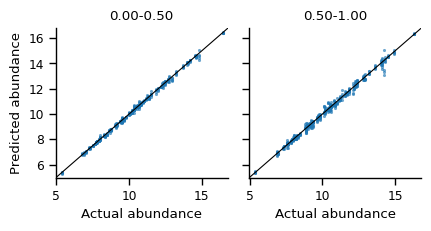

In [7]:
fig, axs = plt.subplots(1, len(t_labels), figsize=(len(t_labels) * 2.2, 2.4), sharex=True, sharey=True)
axs = np.atleast_1d(axs)

axis_min = float(np.nanmin(prediction_summary[["actual", "predicted"]].to_numpy()))
axis_max = float(np.nanmax(prediction_summary[["actual", "predicted"]].to_numpy()))
axis_pad = 0.03 * (axis_max - axis_min)
axis_limits = [axis_min - axis_pad, axis_max + axis_pad]

for ax, t_window in zip(axs, t_labels):
    predicted_t_window = prediction_summary[prediction_summary["t_window"] == t_window]
    sns.scatterplot(
        predicted_t_window,
        x="actual",
        y="predicted",

        s=5,
        linewidth=0,
        alpha=0.65,
        legend=False,
        ax=ax,
    )
    ax.plot(axis_limits, axis_limits, color="k", linewidth=0.8)
    ax.set_title(t_window)
    ax.set_xlabel("Actual abundance")
    ax.set_ylabel("Predicted abundance")
    ax.set_xlim(axis_limits)
    ax.set_ylim(axis_limits)

sns.despine()
plt.tight_layout()

## 2. Cluster Trajectories

In [8]:
velocity_profile_cols = [
    "start_sample",
    "replicate",
    "seed",
    "path_id",
    "trajectory_replicate",
]
velocity_profile_cols = [col for col in velocity_profile_cols if col in runs.columns]

velocity_profile_wide = (
    runs.pivot_table(
        index=velocity_profile_cols,
        columns=["protein", "t"],
        values="velocity",
    )
    .sort_index()
    .sort_index(axis=1)
)

velocity_profile_corr = velocity_profile_wide.T.corr().fillna(0)
np.fill_diagonal(velocity_profile_corr.values, 1)

velocity_profile_distance = (1 - velocity_profile_corr).clip(lower=0).to_numpy()
np.fill_diagonal(velocity_profile_distance, 0)

clusterer = AgglomerativeClustering(
    n_clusters=N_TRAJECTORY_CLUSTERS,

)

trajectory_clusters = velocity_profile_wide.index.to_frame(index=False)
trajectory_clusters["cluster"] = clusterer.fit_predict(velocity_profile_distance) + 1
trajectory_clusters["cluster"] = trajectory_clusters["cluster"].astype(str)

runs = (
    runs.drop(columns=["cluster", "trajectory_cluster"], errors="ignore")
    .merge(
        trajectory_clusters,
        on=velocity_profile_cols,
        how="left",
        validate="many_to_one",
    )
)
cluster_order = sorted(runs["cluster"].dropna().unique(), key=int)

/Users/erikhartman/dev/flow-matching/.venv/lib/python3.12/site-packages/scipy/cluster/hierarchy.py:810: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  return linkage(y, method='ward', metric='euclidean')


## 2b. Pairwise Correlation Clustermap

/Users/erikhartman/dev/flow-matching/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/erikhartman/dev/flow-matching/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Text(275.5555555555556, 0.5, 'Trajectory')

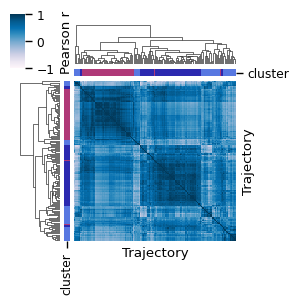

In [9]:
corr_linkage = linkage(squareform(velocity_profile_distance, checks=False), method="average")
profile_cluster_colors = (
    trajectory_clusters
    .set_index(velocity_profile_cols)
    .loc[velocity_profile_corr.index, "cluster"]
    .map(cluster_palette)
)

g = sns.clustermap(
    velocity_profile_corr,
    row_colors=profile_cluster_colors,
    col_colors=profile_cluster_colors,
    cmap="PuBu",
    center=0,
    vmin=-1,
    vmax=1,
    xticklabels=False,
    yticklabels=False,
    figsize=(3,3),
    cbar_kws={"label": "Pearson r"},
)
g.ax_heatmap.set_xlabel("Trajectory")
g.ax_heatmap.set_ylabel("Trajectory")


## 3. UMAP Colored By Cluster

In [10]:
real_wide = (
    df[df["protein"].isin(shared_proteins)]
    .pivot_table(
        index=["File", "time", "WHO grade"],
        columns="protein",
        values="abundance",
    )
    .reindex(columns=shared_proteins)
    .reset_index()
    .rename(columns={"File": "sample", "time": "t"})
)
real_wide["sample_type"] = "real"
real_wide["replicate"] = pd.NA
real_wide["cluster"] = "real"

trajectory_id_cols = [
    "replicate",
    "seed",
    "start_sample",
    "path_id",
    "trajectory_replicate",
    "step",
    "t",
    "datasplit",
    "cluster",
]
trajectory_id_cols = [col for col in trajectory_id_cols if col in runs.columns]

generated_wide = (
    runs[runs["protein"].isin(shared_proteins)]
    .pivot_table(
        index=trajectory_id_cols,
        columns="protein",
        values="abundance",
    )
    .reindex(columns=shared_proteins)
    .reset_index()
)
generated_wide["sample"] = (
    "generated_"
    + generated_wide["replicate"].astype(str)
    + "_"
    + generated_wide["path_id"].astype(str)
    + "_"
    + generated_wide["trajectory_replicate"].astype(str)
    + "_"
    + generated_wide["step"].astype(str)
)
generated_wide["sample_type"] = "generated"

embedding_input = pd.concat(
    [
        real_wide[["sample", "sample_type", "t", "replicate", "cluster", *shared_proteins]],
        generated_wide[["sample", "sample_type", "t", "replicate", "cluster", *shared_proteins]],
    ],
    ignore_index=True,
)

umap_embedder = UMAP(random_state=42)
umap_embedder.fit(real_wide[shared_proteins])
embedding = umap_embedder.transform(embedding_input[shared_proteins])

umap_df = embedding_input[["sample", "sample_type", "t", "replicate", "cluster"]].copy()
umap_df["umap1"] = embedding[:, 0]
umap_df["umap2"] = embedding[:, 1]
umap_df.head()

/Users/erikhartman/dev/flow-matching/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


protein,sample,sample_type,t,replicate,cluster,umap1,umap2
0,520_TOF1_AF_002_ZeBanC_P1_A1,real,1.00,<NA>,real,4.577600,10.208548
1,520_TOF1_AF_003_ZeBanC_P1_A2,real,0.75,<NA>,real,1.625316,11.834004
2,520_TOF1_AF_004_ZeBanC_P1_A3,real,0.75,<NA>,real,1.646994,12.035122
3,520_TOF1_AF_005_ZeBanC_P1_A4,real,0.75,<NA>,real,4.385425,13.663901
4,520_TOF1_AF_006_ZeBanC_P1_A5,real,1.00,<NA>,real,5.161506,12.664869


/var/folders/64/ytcycnwx6w936vfxs5_7q3hm0000gn/T/ipykernel_66688/787426800.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


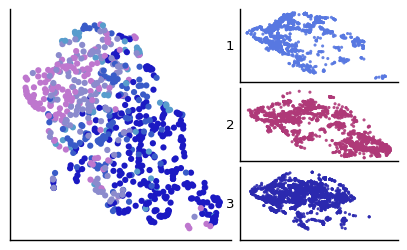

In [11]:
generated_umap = (
    generated_wide[["sample", "step", "t", "cluster"]]
    .merge(
        umap_df[umap_df["sample_type"] == "generated"][["sample", "umap1", "umap2"]],
        on="sample",
        how="left",
    )
    .dropna(subset=["umap1", "umap2", "cluster"])
)

fig = plt.figure(figsize=(5,3))
gs = fig.add_gridspec(3, 2, width_ratios=[1.4, 1], wspace=0.05, hspace=0.08)
ax_real = fig.add_subplot(gs[:, 0])
ax_cluster = [fig.add_subplot(gs[i, 1], sharex=ax_real, sharey=ax_real) for i in range(3)]
real_umap = umap_df[umap_df["sample_type"] == "real"]

sns.scatterplot(real_umap, x="umap1", y="umap2", hue="t", palette=pink_cmap, ax=ax_real,   s=20,
    linewidth=0,)

for cluster, cluster_ax in zip(cluster_order, ax_cluster):
    sns.scatterplot(
        generated_umap[generated_umap["cluster"] == cluster],
        x="umap1",
        y="umap2",
        hue="cluster",
        hue_order=cluster_order,
        palette=cluster_palette,
        s=5,
        alpha=.9,
        linewidth=0,
        legend=False,
        ax=cluster_ax,
    )
    cluster_ax.set_ylabel(str(cluster), rotation=0, ha="right", va="center")

for x in [ax_real, *ax_cluster]:
    x.set_xticks([])
    x.set_yticks([])
    x.set_xlabel("")
    legend = x.get_legend()
    if legend is not None:
        legend.remove()
ax_real.set_ylabel("")
plt.tight_layout()
sns.despine()

## 4. Top Proteins By Cluster

<Figure size 800x200 with 0 Axes>

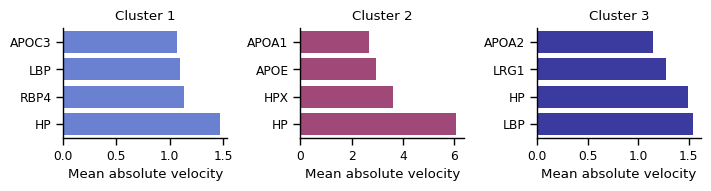

In [12]:
top_proteins_by_cluster = (
    runs.groupby(["cluster", "protein"], observed=True)
    .agg(
        mean_abs_velocity=("abs_velocity", "mean"),
        mean_velocity=("velocity", "mean"),
    )
    .reset_index()
)
top_proteins_by_cluster["rank"] = (
    top_proteins_by_cluster
    .groupby("cluster", observed=True)["mean_abs_velocity"]
    .rank(method="first", ascending=False)
    .astype(int)
)

top_cluster_proteins = top_proteins_by_cluster[
    top_proteins_by_cluster["rank"] <= 4
].copy()
top_proteins = (
    top_cluster_proteins
    .sort_values(["cluster", "rank"])["protein"]
    .drop_duplicates()
    .tolist()
)
plt.figure(figsize=(8,2))
g = sns.catplot(
    data=top_cluster_proteins.sort_values(["cluster", "rank"], ascending=[True, False]),
    x="mean_abs_velocity",
    y="protein",
    col="cluster",
    col_order=cluster_order,
    kind="bar",
    hue="cluster",
    hue_order=cluster_order,
    palette=cluster_palette,
    sharey=False,
    sharex=False,
    height=2,
    aspect=1.2,
    legend=False,
    errorbar = ("ci", 95)
)
g.set_axis_labels("Mean absolute velocity", "")
g.set_titles("Cluster {col_name}")
g.fig.tight_layout()

## 5. Cluster-Level Velocities

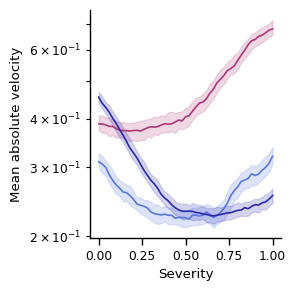

In [13]:
fig, ax = plt.subplots(figsize=(3,3))

sns.lineplot(
    runs,
    x="t",
    y="abs_velocity",
    hue="cluster",
    hue_order=cluster_order,
    palette=cluster_palette,
    estimator="median",
    ax=ax,
)
ax.set_xlabel("Severity")
ax.set_ylabel("Mean absolute velocity")

ax.legend().remove()
sns.despine(ax=ax)
plt.yscale("log")
plt.tight_layout()


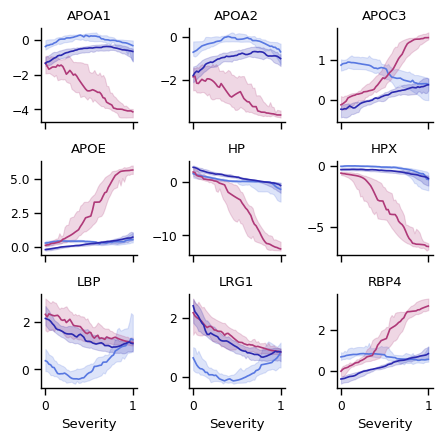

In [14]:
n_cols = min(3, len(top_proteins))
n_rows = int(np.ceil(len(top_proteins) / n_cols))
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.5, n_rows * 1.5), sharex=True)
axs = np.atleast_1d(axs).ravel()
top_proteins = sorted(top_proteins)
for protein, ax in zip(top_proteins, axs):
    run_p = runs[runs["protein"] == protein]
    sns.lineplot(
        run_p,
        x="t",
        y="velocity",
        hue="cluster",
        hue_order=cluster_order,
        palette=cluster_palette,
        estimator="median",
        ax=ax,
    )
    ax.set_title(protein)
    ax.set_xlabel("Severity")
    ax.set_ylabel("")

    ax.legend().remove()
    sns.despine(ax=ax)

for ax in axs[len(top_proteins):]:
    ax.set_axis_off()

fig.tight_layout()